In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


# Variable coding ⑪ — why models differ, and a cheap reliable extractor

Across 22 models coding the same 30 posts into a fixed 37-field schema, the raw exact-match disagreement looked alarming (~28% token-Jaccard). This notebook answers three questions and turns the answer into a **deployable extractor**:

1. **Are the mistakes predictable?** Yes — they're overwhelmingly *how much* a model extracts, not *what* it decides, and *which cell* is coded matters far more than *which model* codes it.
2. **Is the disagreement even real?** On the hardest cells, models agree with **each other** while disagreeing with the gold — so a majority of that 'error' is gold idiosyncrasy, not a model miss.
3. **What's the reliable, cheap recipe?** Three cheap cross-lab models, consensus-gated, with a strong judge panel for the contested minority — but the routing must be **tier-aware**, because the same consensus that is ~5× better than a single model on factual fields is *worse* than one model on the interpretive fields.

*All figures are recomputed from the coding runs, the Opus semantic verdicts, and a fresh model-vs-model semantic judge over the cheap cross-lab trio + grok-4.5.*

In [2]:

import json
import numpy as np
from collections import defaultdict, Counter
from itertools import combinations
DV = r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation"
arch = json.load(open(DV + "/j11_cheap_arch.json", encoding="utf-8"))
cod  = json.load(open(DV + "/j11_coding_runs.json", encoding="utf-8"))
rj   = json.load(open(DV + "/j11_rejudge.json", encoding="utf-8"))["verdicts"]
FIELDS = cod["manifest"]["fields"]
codings = defaultdict(dict)
for c in cod["codings"]: codings[c["model"]][c["sample_id"]] = c["fields"]
gold = {g["sample_id"]: g["fields"] for g in cod["gold"]}
SIDS = sorted(gold); MODELS = sorted(codings)
TIER = {
 "Tier-1": ["age","age_at_onset","infection_count","long_covid_duration_months","time_to_diagnosis",
   "symptom_duration","dosage","procedures","prior_infections","onset_trigger","location_country",
   "biomarker_results","dietary_interventions","vaccination_status","sex_gender","work_disability_status",
   "diagnosis_source","clinical_trial_participation","covid_wave","location_us_state","ethnicity"],
 "Tier-2": ["conditions","medications","alternative_treatments","mental_health","functional_status_tier",
   "activity_level","symptom_trajectory"],
 "Tier-3": ["social_impact","healthcare_costs","diagnostic_odyssey","doctor_dismissal","misdiagnosis",
   "healthcare_system","treatment_outcome","family_history","hormonal_events"]}
FT = {f:t for t,fs in TIER.items() for f in fs}
TCOL = {"Tier-1":"#27ae60","Tier-2":"#e67e22","Tier-3":"#c0392b"}
def pop(v):
    if v is None: return False
    if isinstance(v,list): return any(str(x).strip() and str(x).strip().lower() not in ("n/a","none","unknown") for x in v)
    return bool(str(v).strip()) and str(v).strip().lower() not in ("n/a","none","unknown")
vg = {(r["model"], r["sample_id"], r["field"]): r["verdict"] for r in rj}
display(Markdown(f"*(loaded — {len(MODELS)} models × {len(SIDS)} posts × {len(FIELDS)} fields; "
 f"{len(rj):,} model-vs-gold semantic verdicts; cheap trio = "
 f"{', '.join(m.split('/')[-1] for m in arch['manifest']['trio'])})*"))


*(loaded — 22 models × 30 posts × 37 fields; 4,237 model-vs-gold semantic verdicts; cheap trio = deepseek-v4-flash, gemini-3.1-flash-lite, gpt-5-mini)*

## 1. The disagreement is predictable and structural

Two facts reframe the scary Jaccard number. First, **most 'errors' are extraction *quantity*** — a model asserting a field the gold left empty (over-extraction) or missing one it filled (under-extraction) — not two models picking genuinely conflicting *values*. Second, the error is concentrated by **field type**: the 37 fields fall into three tiers, and the diff-rate climbs steeply from factual to interpretive fields.

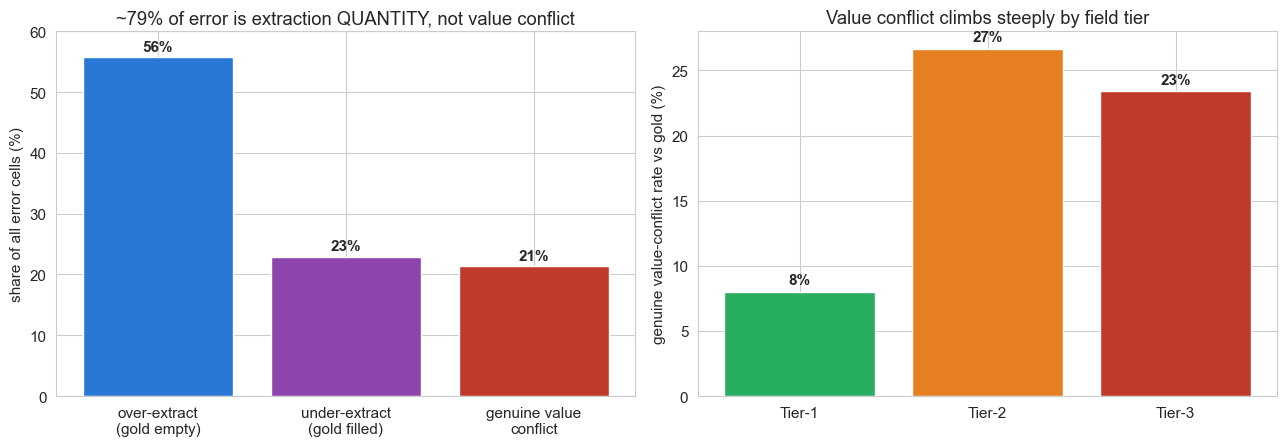

**79% of all error is over/under-extraction** (1,944 over, 801 under across the roster); only **21%** is a genuine value conflict. Over/under lean is forecastable from a model's fill-rate — verbose models over-fill, terse models under-fill — so it's a stable, correctable trait, not noise. And the genuine conflicts pile up by tier: **Tier-1 8% → Tier-2 27% → Tier-3 23%**. The tier a field lives in predicts its reliability far better than the model does — which is exactly what the extractor below exploits.

In [3]:

# error composition across all 22 models: over-extract / under-extract / genuine value conflict
over=under=genuine=coval=0
for m in MODELS:
    for s in SIDS:
        for f in FIELDS:
            mp=pop(codings[m].get(s,{}).get(f)); gp=pop(gold[s].get(f))
            if mp and gp:
                coval+=1
                if vg.get((m,s,f))=="different": genuine+=1
            elif mp and not gp: over+=1
            elif gp and not mp: under+=1
tot_err=over+under+genuine
# per-tier genuine diff-rate (co-populated only)
tier_diff={}
for t,fs in TIER.items():
    dd=nn=0
    for m in MODELS:
        for s in SIDS:
            for f in fs:
                if pop(codings[m].get(s,{}).get(f)) and pop(gold[s].get(f)):
                    nn+=1; dd += (vg.get((m,s,f))=="different")
    tier_diff[t]=(dd/nn if nn else 0, nn)
fig,ax=plt.subplots(1,2,figsize=(13,4.6))
ax[0].bar(["over-extract\n(gold empty)","under-extract\n(gold filled)","genuine value\nconflict"],
          [over/tot_err*100,under/tot_err*100,genuine/tot_err*100],
          color=["#2a78d6","#8e44ad","#c0392b"])
for i,v in enumerate([over,under,genuine]): ax[0].text(i,v/tot_err*100+1,f"{v/tot_err:.0%}",ha="center",fontweight="bold")
ax[0].set_ylabel("share of all error cells (%)"); ax[0].set_ylim(0,60)
ax[0].set_title(f"~{(over+under)/tot_err:.0%} of error is extraction QUANTITY, not value conflict")
ax[1].bar(list(tier_diff), [tier_diff[t][0]*100 for t in tier_diff], color=[TCOL[t] for t in tier_diff])
for i,t in enumerate(tier_diff): ax[1].text(i,tier_diff[t][0]*100+0.6,f"{tier_diff[t][0]:.0%}",ha="center",fontweight="bold")
ax[1].set_ylabel("genuine value-conflict rate vs gold (%)")
ax[1].set_title("Value conflict climbs steeply by field tier")
fig.tight_layout(); plt.show()
display(Markdown(
 f"**{(over+under)/tot_err:.0%} of all error is over/under-extraction** ({over:,} over, {under:,} under across "
 f"the roster); only **{genuine/tot_err:.0%}** is a genuine value conflict. Over/under lean is forecastable from "
 f"a model's fill-rate — verbose models over-fill, terse models under-fill — so it's a stable, correctable "
 f"trait, not noise. And the genuine conflicts pile up by tier: **Tier-1 {tier_diff['Tier-1'][0]:.0%} → "
 f"Tier-2 {tier_diff['Tier-2'][0]:.0%} → Tier-3 {tier_diff['Tier-3'][0]:.0%}**. The tier a field lives in "
 f"predicts its reliability far better than the model does — which is exactly what the extractor below exploits."))


## 2. Is the disagreement even real? — the blind-spot cross-check

The sharpest test of whether that error is *model* error or *gold* idiosyncrasy: take the cells where **≥50% of the 22 models disagree with the Opus gold**, and ask whether those models agree **with each other**. If they do, the gold is the outlier, not the models. We judged this with a fresh Opus semantic pass over four models (the three cheap cross-lab producers + grok-4.5).

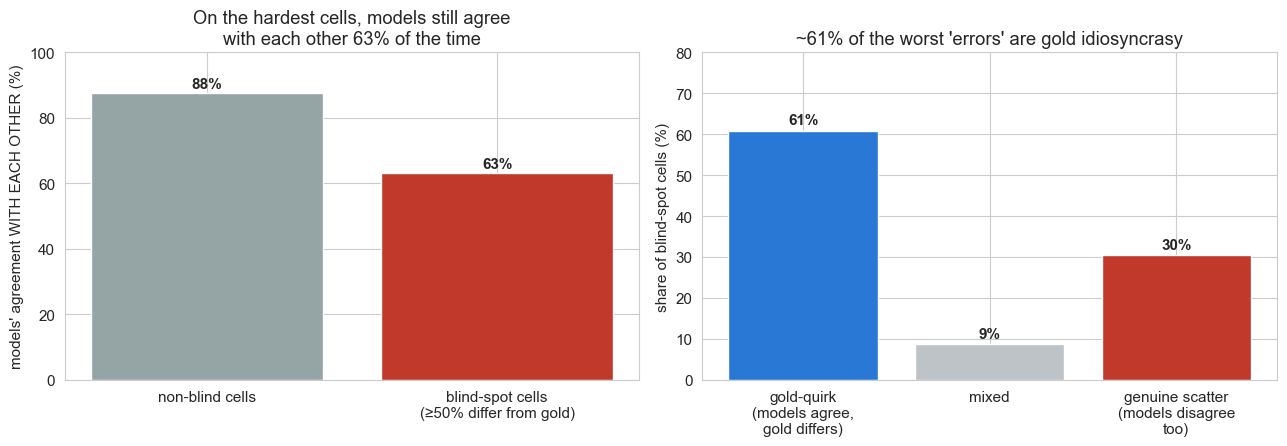

On blind-spot cells the four models still agree with **each other 63%** of the time (vs 88% elsewhere), and **61% of those cells are gold-quirk** — the models converge on a reading the gold doesn't share. So the raw diff-rate *overstates* true model error: a large slice of it is the gold being sparse, picking one of several valid readings, or coding at a different granularity. The genuine model-miss floor sits **below** the headline number (n=23 blind-spot cells — directional, not precise).

tier,field,gold value,what the models say
Tier-2,activity_level,"['bedbound', 'unable to work for over a year']",deepseek-v4-flash:['limited'] · gemini-3.1-flash-lite:['housebound']
Tier-2,activity_level,"['completely on sick leave', 'fully recovered (one commenter)', 'no si","deepseek-v4-flash:['fully recovered', 'housebound', · grok-4.5:['fully recovered']"
Tier-2,symptom_trajectory,"['no signs of improvement', 'gradually worsened']","deepseek-v4-flash:['recovered', 'no improvement', 'g · gpt-5-mini:['gradually worsened until complet"
Tier-3,healthcare_system,"['alberta (canada)', 'another canadian province']","gemini-3.1-flash-lite:['us (massachusetts)', 'canada (al · gpt-5-mini:['us — massachusetts (brigham and"
Tier-1,symptom_duration,"['6 months (new arm symptom)', 'since day one / beginning (arm weaknes",deepseek-v4-flash:['6 months (since onset of new sym · gpt-5-mini:['new right arm symptom occurred a
Tier-2,conditions,"['mcas', 'severe anhedonia', 'consummatory anhedonia', 'emotional blun","deepseek-v4-flash:['mcas', 'anhedonia', 'seasonal al · gemini-3.1-flash-lite:['mcas', 'anhedonia', 'consummator"


In [4]:

pa=arch["partA"]
fig,ax=plt.subplots(1,2,figsize=(13,4.6))
ax[0].bar(["non-blind cells","blind-spot cells\n(≥50% differ from gold)"],
          [pa["mutual_agree_non_blind"]*100, pa["mutual_agree_blind"]*100], color=["#95a5a6","#c0392b"])
for i,v in enumerate([pa["mutual_agree_non_blind"],pa["mutual_agree_blind"]]):
    ax[0].text(i,v*100+1.5,f"{v:.0%}",ha="center",fontweight="bold")
ax[0].set_ylabel("models' agreement WITH EACH OTHER (%)"); ax[0].set_ylim(0,100)
ax[0].set_title("On the hardest cells, models still agree\nwith each other 63% of the time")
seg=[pa["quirk_share"],pa["mid_share"],pa["genuine_share"]]
ax[1].bar(["gold-quirk\n(models agree,\ngold differs)","mixed","genuine scatter\n(models disagree\ntoo)"],
          [x*100 for x in seg], color=["#2a78d6","#bdc3c7","#c0392b"])
for i,v in enumerate(seg): ax[1].text(i,v*100+1.5,f"{v:.0%}",ha="center",fontweight="bold")
ax[1].set_ylabel("share of blind-spot cells (%)"); ax[1].set_ylim(0,80)
ax[1].set_title(f"~{pa['quirk_share']:.0%} of the worst 'errors' are gold idiosyncrasy")
fig.tight_layout(); plt.show()
display(Markdown(
 f"On blind-spot cells the four models still agree with **each other {pa['mutual_agree_blind']:.0%}** of the "
 f"time (vs {pa['mutual_agree_non_blind']:.0%} elsewhere), and **{pa['quirk_share']:.0%} of those cells are "
 f"gold-quirk** — the models converge on a reading the gold doesn't share. So the raw diff-rate *overstates* "
 f"true model error: a large slice of it is the gold being sparse, picking one of several valid readings, or "
 f"coding at a different granularity. The genuine model-miss floor sits **below** the headline number "
 f"(n={pa['n_blind']} blind-spot cells — directional, not precise)."))
ex=arch["partA_examples"]
rows=[[e["tier"], e["field"], str(e["gold"])[:70], " · ".join(f"{k}:{str(v)[:34]}" for k,v in list(e["models_agree_on"].items())[:2])] for e in ex[:6]]
display(HTML("<b>Gold-quirk examples — models converge, gold differs</b>"+
 pd.DataFrame(rows,columns=["tier","field","gold value","what the models say"]).to_html(index=False)))


## 3. The cheap extractor — 3 cross-lab models, consensus-gated

The deployable recipe: run **three cheap models from three different labs** (`deepseek-v4-flash` · `gemini-3.1-flash-lite` · `gpt-5-mini`) and gate on **cross-lab agreement**. A cell where ≥2 of them agree (semantically) is auto-accepted; all-three-empty is auto-accepted as absent; anything else escalates to a judge. The headline: **on factual (Tier-1) fields, three cheap models beat every single model — including the best one.**

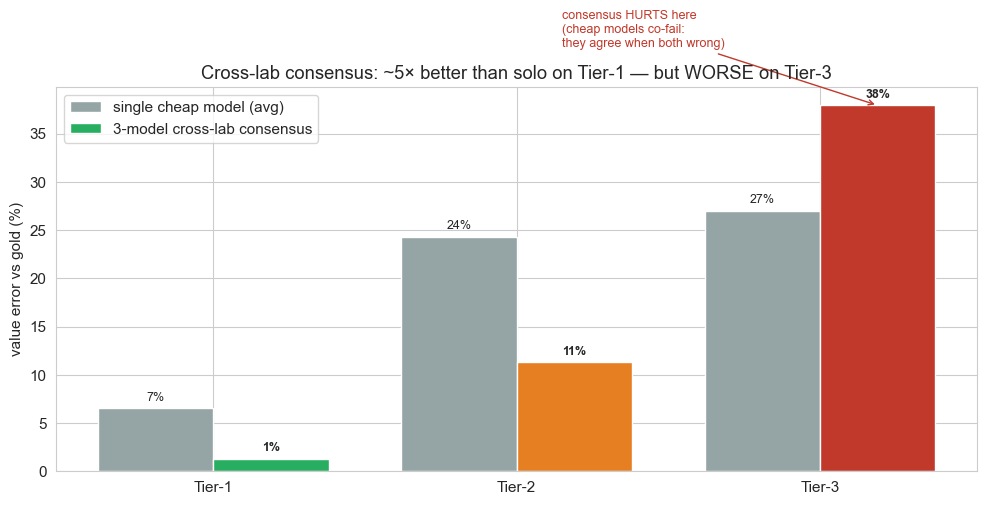

- **Tier-1 (21 factual fields): consensus 1.3% vs solo 7% — ~5× lower**, and below even grok-4.5 solo (4%). Three $0.10–0.25 models cross-checking beat one $2 model. This is where consensus earns its keep.
- **Tier-2 (7 list fields): consensus 11% vs solo 24% — ~2× lower.** Helps, but still leaks — the cheap producers co-fail on partial lists (agree on the same incomplete set).
- **Tier-3 (9 interpretive fields): consensus 38% vs solo 27% — consensus is *worse*.** When two cheap models agree on an interpretive field they are disproportionately **co-failing** (or the gold is quirky, §2). Agreement is anti-correlated with correctness here, so the gate *selects for* shared error. **Never auto-accept cheap consensus on Tier-3.** (n=29 value cells — wide bar, but the direction matches the co-failure mechanism.)

In [5]:

tiers=list(TIER); x=np.arange(len(tiers)); w=0.38
cons=[arch["partB"]["strict"]["tiers"][t]["value_consensus_error"]*100 for t in tiers]
solo=[arch["solo_tier_err"][t]*100 for t in tiers]
fig,ax=plt.subplots(figsize=(10,5.2))
b1=ax.bar(x-w/2,solo,w,label="single cheap model (avg)",color="#95a5a6")
b2=ax.bar(x+w/2,cons,w,label="3-model cross-lab consensus",color=[TCOL[t] for t in tiers])
for i,(a,b) in enumerate(zip(solo,cons)):
    ax.text(i-w/2,a+0.8,f"{a:.0f}%",ha="center",fontsize=9)
    ax.text(i+w/2,b+0.8,f"{b:.0f}%",ha="center",fontsize=9,fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(tiers); ax.set_ylabel("value error vs gold (%)")
ax.legend(); ax.set_title("Cross-lab consensus: ~5× better than solo on Tier-1 — but WORSE on Tier-3")
ax.annotate("consensus HURTS here\n(cheap models co-fail:\nthey agree when both wrong)",
 xy=(2+w/2,cons[2]), xytext=(1.15,44), fontsize=9, color="#c0392b",
 arrowprops=dict(arrowstyle="->",color="#c0392b"))
fig.tight_layout(); plt.show()
grok=[b for b in arch["baselines"] if b["model"]=="grok-4.5"][0]
display(Markdown(
 f"- **Tier-1 (21 factual fields): consensus {cons[0]:.1f}% vs solo {solo[0]:.0f}% — ~"
 f"{solo[0]/cons[0]:.0f}× lower**, and below even grok-4.5 solo ({grok['tier_error']['Tier-1']:.0%}). "
 f"Three $0.10–0.25 models cross-checking beat one $2 model. This is where consensus earns its keep.\n"
 f"- **Tier-2 (7 list fields): consensus {cons[1]:.0f}% vs solo {solo[1]:.0f}% — ~{solo[1]/cons[1]:.0f}× lower.** "
 f"Helps, but still leaks — the cheap producers co-fail on partial lists (agree on the same incomplete set).\n"
 f"- **Tier-3 (9 interpretive fields): consensus {cons[2]:.0f}% vs solo {solo[2]:.0f}% — consensus is *worse*.** "
 f"When two cheap models agree on an interpretive field they are disproportionately **co-failing** (or the gold "
 f"is quirky, §2). Agreement is anti-correlated with correctness here, so the gate *selects for* shared error. "
 f"**Never auto-accept cheap consensus on Tier-3.** (n=29 value cells — wide bar, but the direction matches the "
 f"co-failure mechanism.)"))


## 4. Coverage, escalation, and the judge panel

How much of the work the cheap trio clears on its own, and what's left for the judge. The escalated cells — where the cheap models *don't* reach cross-lab agreement — are exactly the hard, contested ones, which is precisely where the expensive judge budget should go.

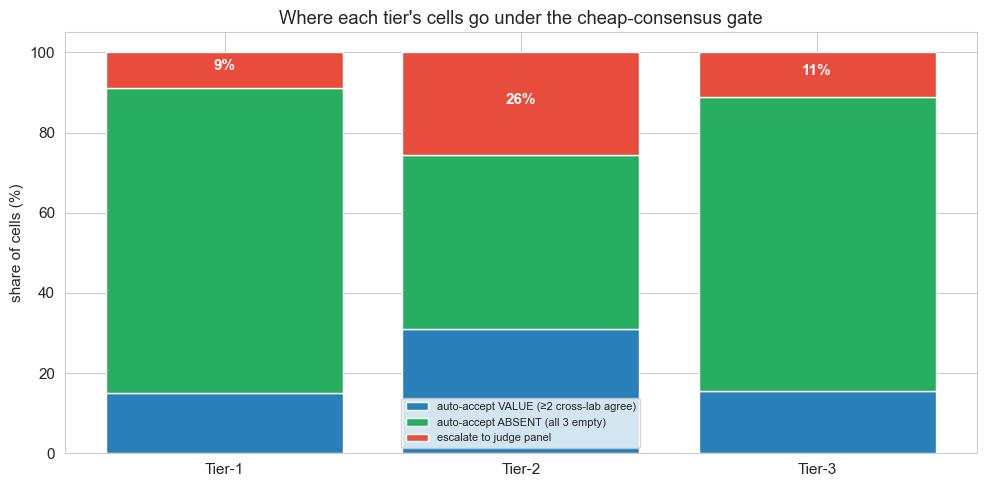

Under the plain gate the trio auto-resolves **87%** of cells and escalates 13%. But because Tier-3 value-consensus can't be trusted (§3), the **recommended tiered policy** additionally routes *all* populated Tier-3 cells to the judge. Net: **auto-resolve 84% of cells at 95.0% accuracy, judge panel on 16%** (182 of 1110 cells).

**The judge panel must be strong, not cheap.** The escalated cells are the interpretive/contested ones where cheap models co-fail — an earlier cheap-judge test found free judges are either yes-men (~61% false-confirm) or too slow, so a cheap panel would rubber-stamp the co-failures. Use a strong adjudicator (grok-4.5 at 10% solo, or Opus) — and for Tier-3, where even the gold is soft, a 2-of-{Opus, grok, human} panel.

In [6]:

tiers=list(TIER); x=np.arange(len(tiers))
av=[arch["partB"]["strict"]["tiers"][t]["accept_value"] for t in tiers]
ab=[arch["partB"]["strict"]["tiers"][t]["accept_absent"] for t in tiers]
es=[arch["partB"]["strict"]["tiers"][t]["escalate"] for t in tiers]
tot=[a+b+c for a,b,c in zip(av,ab,es)]
avp=[a/t*100 for a,t in zip(av,tot)]; abp=[b/t*100 for b,t in zip(ab,tot)]; esp=[c/t*100 for c,t in zip(es,tot)]
fig,ax=plt.subplots(figsize=(10,5))
ax.bar(x,avp,color="#2980b9",label="auto-accept VALUE (≥2 cross-lab agree)")
ax.bar(x,abp,bottom=avp,color="#27ae60",label="auto-accept ABSENT (all 3 empty)")
ax.bar(x,esp,bottom=[a+b for a,b in zip(avp,abp)],color="#e74c3c",label="escalate to judge panel")
for i in range(len(tiers)):
    ax.text(i,esp[i]/2+avp[i]+abp[i],f"{esp[i]:.0f}%",ha="center",color="white",fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(tiers); ax.set_ylabel("share of cells (%)"); ax.set_ylim(0,105)
ax.legend(loc="lower center",fontsize=8); ax.set_title("Where each tier's cells go under the cheap-consensus gate")
fig.tight_layout(); plt.show()
pol=arch["policy"]
display(Markdown(
 f"Under the plain gate the trio auto-resolves **{arch['partB']['strict']['overall']['coverage']:.0%}** of cells "
 f"and escalates {arch['partB']['strict']['overall']['escalation_rate']:.0%}. But because Tier-3 value-consensus "
 f"can't be trusted (§3), the **recommended tiered policy** additionally routes *all* populated Tier-3 cells to "
 f"the judge. Net: **auto-resolve {pol['auto_rate']:.0%} of cells at {pol['auto_accuracy']:.1%} accuracy, judge "
 f"panel on {pol['judge_call_rate']:.0%}** ({pol['judge_calls']} of {pol['total']} cells).\n\n"
 f"**The judge panel must be strong, not cheap.** The escalated cells are the interpretive/contested ones where "
 f"cheap models co-fail — an earlier cheap-judge test found free judges are either yes-men (~61% false-confirm) "
 f"or too slow, so a cheap panel would rubber-stamp the co-failures. Use a strong adjudicator (grok-4.5 at "
 f"{grok['value_error']:.0%} solo, or Opus) — and for Tier-3, where even the gold is soft, a 2-of-{{Opus, grok, "
 f"human}} panel."))


## 5. The recommended pipeline

In [7]:

pol=arch["policy"]; ov=arch["partB"]["strict"]["overall"]
rows=[
 ["Tier-1 (21 factual fields)","3-model cross-lab consensus → auto-accept",
  f"{arch['partB']['strict']['tiers']['Tier-1']['value_consensus_error']:.0%} error; escalate only the ~9% contested"],
 ["Tier-2 (7 list fields)","consensus, but require all-3 or escalate contested",
  f"{arch['partB']['strict']['tiers']['Tier-2']['value_consensus_error']:.0%} residual leak → spot-check with judge"],
 ["Tier-3 (9 interpretive)","consensus for ABSENCE only; route ALL values to judge panel",
  "cheap consensus worse than solo here — do not trust it"],
 ["Judge panel","strong adjudicator (grok-4.5 / Opus); 2-of-3 w/ human on Tier-3",
  f"fires on ~{pol['judge_call_rate']:.0%} of cells — the hard minority"],
 ["Single-model fallback","grok-4.5 if only one model affordable",
  "10.3% overall; but the trio strictly dominates it on Tier-1/2"],
]
display(HTML("<b>Tier-aware extraction pipeline</b>"+
 pd.DataFrame(rows,columns=["stage","rule","note"]).to_html(index=False,escape=False)))
display(Markdown(
 f"**Bottom line.** Model disagreement in ⑪ is predictable (over/under-fill, item ≫ model) and largely a "
 f"formatting/gold-granularity artifact, not chaotic judgment. The reliable-and-cheap extractor is **three "
 f"cheap cross-lab models gated on agreement, routed by tier**: near-free and ~5× better than any single model "
 f"on the factual covariates, consensus-plus-judge on the list fields, and **judge-panel-only on the "
 f"interpretive fields where cheap agreement is a trap**. That auto-resolves **{pol['auto_rate']:.0%}** of cells "
 f"at **{pol['auto_accuracy']:.1%}** accuracy while spending the expensive judge on the **{pol['judge_call_rate']:.0%}** "
 f"that actually need it — versus running Opus on 100%."))


stage,rule,note
Tier-1 (21 factual fields),3-model cross-lab consensus → auto-accept,1% error; escalate only the ~9% contested
Tier-2 (7 list fields),"consensus, but require all-3 or escalate contested",11% residual leak → spot-check with judge
Tier-3 (9 interpretive),consensus for ABSENCE only; route ALL values to judge panel,cheap consensus worse than solo here — do not trust it
Judge panel,strong adjudicator (grok-4.5 / Opus); 2-of-3 w/ human on Tier-3,fires on ~16% of cells — the hard minority
Single-model fallback,grok-4.5 if only one model affordable,10.3% overall; but the trio strictly dominates it on Tier-1/2


**Bottom line.** Model disagreement in ⑪ is predictable (over/under-fill, item ≫ model) and largely a formatting/gold-granularity artifact, not chaotic judgment. The reliable-and-cheap extractor is **three cheap cross-lab models gated on agreement, routed by tier**: near-free and ~5× better than any single model on the factual covariates, consensus-plus-judge on the list fields, and **judge-panel-only on the interpretive fields where cheap agreement is a trap**. That auto-resolves **84%** of cells at **95.0%** accuracy while spending the expensive judge on the **16%** that actually need it — versus running Opus on 100%.

## Limitations

- **30 posts.** Tier-3 value-consensus rests on n=29 cells — the "consensus worse than solo" direction is
  robust to the mechanism (co-failure + gold-quirk both push it), but the 38% point value has a wide bar.
  Scale the trio + judge run on a larger sample before pinning tier thresholds.
- **Measured against Opus-gold**, which itself disagrees with the Luna/Sol golds 13–16% and over-selects one
  reading on interpretive fields (§2 shows a majority of the worst "errors" are gold idiosyncrasy). Tier-1
  accuracy is trustworthy; Tier-3 "error" is partly a gold artifact, which is *another* reason to escalate it.
- **"Agree" = Opus semantic-equivalence** over the cheap trio's outputs. A different judge could shift the
  consensus set slightly; the tier ordering is stable, the second decimal is not.
- **Cost is illustrative** — cheap producers ~$0.10–0.25/1M vs Opus $5/1M; the judge-call rate (~16%) is the
  real cost driver, and it's dominated by Tier-2/3. Actual $/1k-posts depends on batch sizing.
- Measures reliability of an extraction step against a model gold, not any treatment effect. Not medical advice.

In [8]:

m=arch["manifest"]
prov=pd.DataFrame({"item":["producers","strong ref / judge","gold","semantic judge","posts × fields","method"],
 "value":[", ".join(x.split("/")[-1] for x in m["trio"]), m["strong_ref"].split("/")[-1],
          m["gold"].split("/")[-1], "anthropic/claude-opus-4.8 (equivalence)", f"{len(SIDS)} × {len(FIELDS)}",
          "cross-lab consensus gate + tier-differentiated escalation"]})
display(HTML("<b>Provenance</b>"+prov.to_html(index=False)))
display(HTML('<div style="font-size:1.15em;font-weight:bold;font-style:italic;margin-top:1em">'
             'Measures an extraction step’s reliability against a model gold, not treatment effects. Not medical advice.</div>'))


item,value
producers,"deepseek-v4-flash, gemini-3.1-flash-lite, gpt-5-mini"
strong ref / judge,grok-4.5
gold,claude-opus-4.8
semantic judge,anthropic/claude-opus-4.8 (equivalence)
posts × fields,30 × 37
method,cross-lab consensus gate + tier-differentiated escalation
